# Packages

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../data/A0008D - v_pt_ride_all (full).csv')

In [4]:
df['BIZ_DT'] = pd.to_datetime(df['BIZ_DT'])
df['ENTRY_DT'] = pd.to_datetime(df['ENTRY_DT'])
df['EXIT_DT'] = pd.to_datetime(df['EXIT_DT'])
#df['ENTRY_TM'] = pd.to_datetime(df['ENTRY_TM'], format='%H:%M:%S.%f')
#df['EXIT_TM'] = pd.to_datetime(df['EXIT_TM'], format='%H:%M:%S.%f')

In [5]:
df1 = df[df['ENTRY_DT'] == '2025-02-11'].copy()
df1.columns
df2 = df1[['BUS_SVC_NUM', 'CRD_NUM', 'DEST_LOC_ID_NUM', 'ENTRY_DT',
       'ENTRY_TM', 'EXIT_DT', 'EXIT_TM', 'ORIG_LOC_ID_NUM', 'RIDE_DISC_AMT', 'RIDE_DIST_KM_CNT',
       'RIDE_FARE_AMT', 'RIDE_ID_NUM', 'RIDE_MIN_CNT']].reset_index()
df2.head()

,index,BUS_SVC_NUM,CRD_NUM,DEST_LOC_ID_NUM,ENTRY_DT,ENTRY_TM,EXIT_DT,EXIT_TM,ORIG_LOC_ID_NUM,RIDE_DISC_AMT,RIDE_DIST_KM_CNT,RIDE_FARE_AMT,RIDE_ID_NUM,RIDE_MIN_CNT
0,58167,62.0,200003194601,6492,2025-02-11,00:47:26.000,2025-02-11,01:13:17.000,3979,0.0,9.1,1.73,110848327669,25.850
1,59621,117.0,230021568683,6034,2025-02-11,00:23:54.000,2025-02-11,00:29:20.000,6042,0.0,1.1,1.19,110848360426,5.433
2,60686,NaN,230036729632,325,2025-02-11,00:03:46.000,2025-02-11,00:18:29.000,320,0.0,6.1,1.50,110848362684,14.717
3,61474,235.0,2190006112681,3380,2025-02-11,00:33:00.000,2025-02-11,00:36:29.000,6984,0.0,0.8,0.00,110848329634,3.483
4,61528,979.0,190002646194,2997,2025-02-11,00:01:31.000,2025-02-11,00:29:25.000,6901,0.0,6.7,0.24,110848330026,27.900


In [6]:
bus_data = pd.read_csv('../data/A0008D - v_q_bus_stop (full).csv')

In [7]:
df2 = df2.merge(bus_data, how = 'left', left_on= 'DEST_LOC_ID_NUM',
                right_on= 'MRK_ID_NUM')
df2.head(5)

,index,BUS_SVC_NUM,CRD_NUM,DEST_LOC_ID_NUM,ENTRY_DT,ENTRY_TM,EXIT_DT,EXIT_TM,ORIG_LOC_ID_NUM,RIDE_DISC_AMT,RIDE_DIST_KM_CNT,RIDE_FARE_AMT,RIDE_ID_NUM,RIDE_MIN_CNT,BUS_STOP_CD,BUS_STOP_NAM,MRK_ID_NUM,RD_NAM
0,58167,62.0,200003194601,6492,2025-02-11,00:47:26.000,2025-02-11,01:13:17.000,3979,0.0,9.1,1.73,110848327669,25.850,65179.0,Coral Edge Stn Exit A,6492.0,Punggol Field
1,59621,117.0,230021568683,6034,2025-02-11,00:23:54.000,2025-02-11,00:29:20.000,6042,0.0,1.1,1.19,110848360426,5.433,58519.0,Opp Blk 104B,6034.0,CANBERRA ST
2,60686,NaN,230036729632,325,2025-02-11,00:03:46.000,2025-02-11,00:18:29.000,320,0.0,6.1,1.50,110848362684,14.717,NaN,NaN,NaN,NaN
3,61474,235.0,2190006112681,3380,2025-02-11,00:33:00.000,2025-02-11,00:36:29.000,6984,0.0,0.8,0.00,110848329634,3.483,52161.0,Braddell Stn/Blk 111,3380.0,LOR 1 TOA PAYOH
4,61528,979.0,190002646194,2997,2025-02-11,00:01:31.000,2025-02-11,00:29:25.000,6901,0.0,6.7,0.24,110848330026,27.900,45399.0,Regent Gr Condo,2997.0,CHOA CHU KANG NORTH 7


In [8]:
df2 = df2.rename(columns={
    'BUS_STOP_CD': 'DEST_BUS_STOP_CD',
    'BUS_STOP_NAM': 'DEST_BUS_STOP_NAM',
    'MRK_ID_NUM': 'DEST_MRK_ID_NUM',
    'RD_NAM': 'DEST_RD_NAM',
})

In [9]:
df2 = df2.merge(bus_data, how = 'left', left_on= 'ORIG_LOC_ID_NUM',
                right_on= 'MRK_ID_NUM')

In [10]:
df2 = df2.rename(columns={
    'BUS_STOP_CD': 'ORIG_BUS_STOP_CD',
    'BUS_STOP_NAM': 'ORIG_BUS_STOP_NAM',
    'MRK_ID_NUM': 'ORIG_MRK_ID_NUM',
    'RD_NAM': 'ORIG_RD_NAM',
})
df2.head(5)

,index,BUS_SVC_NUM,CRD_NUM,DEST_LOC_ID_NUM,ENTRY_DT,ENTRY_TM,EXIT_DT,EXIT_TM,ORIG_LOC_ID_NUM,RIDE_DISC_AMT,...,RIDE_ID_NUM,RIDE_MIN_CNT,DEST_BUS_STOP_CD,DEST_BUS_STOP_NAM,DEST_MRK_ID_NUM,DEST_RD_NAM,ORIG_BUS_STOP_CD,ORIG_BUS_STOP_NAM,ORIG_MRK_ID_NUM,ORIG_RD_NAM
0,58167,62.0,200003194601,6492,2025-02-11,00:47:26.000,2025-02-11,01:13:17.000,3979,0.0,...,110848327669,25.850,65179.0,Coral Edge Stn Exit A,6492.0,Punggol Field,62229.0,The Minton,3979.0,Lor Ah Soo
1,59621,117.0,230021568683,6034,2025-02-11,00:23:54.000,2025-02-11,00:29:20.000,6042,0.0,...,110848360426,5.433,58519.0,Opp Blk 104B,6034.0,CANBERRA ST,58549.0,Canberra Stn,6042.0,CANBERRA LK
2,60686,NaN,230036729632,325,2025-02-11,00:03:46.000,2025-02-11,00:18:29.000,320,0.0,...,110848362684,14.717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,61474,235.0,2190006112681,3380,2025-02-11,00:33:00.000,2025-02-11,00:36:29.000,6984,0.0,...,110848329634,3.483,52161.0,Braddell Stn/Blk 111,3380.0,LOR 1 TOA PAYOH,52559.0,Caldecott Stn Exit 1,6984.0,TOA PAYOH LK
4,61528,979.0,190002646194,2997,2025-02-11,00:01:31.000,2025-02-11,00:29:25.000,6901,0.0,...,110848330026,27.900,45399.0,Regent Gr Condo,2997.0,CHOA CHU KANG NORTH 7,45009.0,Bukit Panjang Interchange B3,6901.0,JELEBU RD


In [11]:
bus_vls_data = pd.read_csv('../data/A0008D - v_q_vls_marker (full).csv')

In [12]:
df3 = df2.merge(bus_vls_data, how = 'left', left_on= 'DEST_MRK_ID_NUM',
                right_on= 'MRK_ID_NUM')
df3 = df3.rename(columns={
    'LATITUDE_VAL': 'DEST_LATITUDE_VAL',
    'LONGITUDE_VAL': 'DEST_LONGITUDE_VAL',
})
df3.head(3)

,index,BUS_SVC_NUM,CRD_NUM,DEST_LOC_ID_NUM,ENTRY_DT,ENTRY_TM,EXIT_DT,EXIT_TM,ORIG_LOC_ID_NUM,RIDE_DISC_AMT,...,DEST_BUS_STOP_NAM,DEST_MRK_ID_NUM,DEST_RD_NAM,ORIG_BUS_STOP_CD,ORIG_BUS_STOP_NAM,ORIG_MRK_ID_NUM,ORIG_RD_NAM,MRK_ID_NUM,DEST_LATITUDE_VAL,DEST_LONGITUDE_VAL
0,58167,62.0,200003194601,6492,2025-02-11,00:47:26.000,2025-02-11,01:13:17.000,3979,0.0,...,Coral Edge Stn Exit A,6492.0,Punggol Field,62229.0,The Minton,3979.0,Lor Ah Soo,6492.0,5019504.0,374083039.0
1,59621,117.0,230021568683,6034,2025-02-11,00:23:54.000,2025-02-11,00:29:20.000,6042,0.0,...,Opp Blk 104B,6034.0,CANBERRA ST,58549.0,Canberra Stn,6042.0,CANBERRA LK,6034.0,5212670.0,373789443.0
2,60686,NaN,230036729632,325,2025-02-11,00:03:46.000,2025-02-11,00:18:29.000,320,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df3 = df3.merge(bus_vls_data, how = 'left', left_on= 'ORIG_MRK_ID_NUM',
                right_on= 'MRK_ID_NUM')
df3 = df3.rename(columns={
    'LATITUDE_VAL': 'ORIG_LATITUDE_VAL',
    'LONGITUDE_VAL': 'ORIG_LONGITUDE_VAL',
})
df3.head(5)

,index,BUS_SVC_NUM,CRD_NUM,DEST_LOC_ID_NUM,ENTRY_DT,ENTRY_TM,EXIT_DT,EXIT_TM,ORIG_LOC_ID_NUM,RIDE_DISC_AMT,...,ORIG_BUS_STOP_CD,ORIG_BUS_STOP_NAM,ORIG_MRK_ID_NUM,ORIG_RD_NAM,MRK_ID_NUM_x,DEST_LATITUDE_VAL,DEST_LONGITUDE_VAL,MRK_ID_NUM_y,ORIG_LATITUDE_VAL,ORIG_LONGITUDE_VAL
0,58167,62.0,200003194601,6492,2025-02-11,00:47:26.000,2025-02-11,01:13:17.000,3979,0.0,...,62229.0,The Minton,3979.0,Lor Ah Soo,6492.0,5019504.0,374083039.0,3979.0,4863864.0,373975849.0
1,59621,117.0,230021568683,6034,2025-02-11,00:23:54.000,2025-02-11,00:29:20.000,6042,0.0,...,58549.0,Canberra Stn,6042.0,CANBERRA LK,6034.0,5212670.0,373789443.0,6042.0,5193281.0,373788511.0
2,60686,NaN,230036729632,325,2025-02-11,00:03:46.000,2025-02-11,00:18:29.000,320,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,61474,235.0,2190006112681,3380,2025-02-11,00:33:00.000,2025-02-11,00:36:29.000,6984,0.0,...,52559.0,Caldecott Stn Exit 1,6984.0,TOA PAYOH LK,3380.0,4827108.0,373843642.0,6984.0,4811407.0,373822679.0
4,61528,979.0,190002646194,2997,2025-02-11,00:01:31.000,2025-02-11,00:29:25.000,6901,0.0,...,45009.0,Bukit Panjang Interchange B3,6901.0,JELEBU RD,2997.0,5039427.0,373499686.0,6901.0,4963266.0,373546001.0


Plot Hexbin Density Map

In [14]:
print(df3[['ORIG_LATITUDE_VAL','ORIG_LONGITUDE_VAL']].describe())

       ORIG_LATITUDE_VAL  ORIG_LONGITUDE_VAL
count       2.401905e+06        2.401905e+06
mean        4.879543e+06        3.738097e+08
std         1.601380e+05        1.136080e+06
min         0.000000e+00        0.000000e+00
25%         4.767163e+06        3.735908e+08
50%         4.861086e+06        3.738374e+08
75%         4.965210e+06        3.740134e+08
max         5.383588e+06        3.745080e+08


In [ ]:
#import packages
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import seaborn as sns
import pyproj

In [16]:
# drop rows with 0 or NaN in coordinates
df3_clean = df3.dropna(subset=['ORIG_LATITUDE_VAL','ORIG_LONGITUDE_VAL',
                               'DEST_LATITUDE_VAL','DEST_LONGITUDE_VAL'])
df3_clean = df3_clean[(df3_clean['ORIG_LATITUDE_VAL']>0) & (df3_clean['ORIG_LONGITUDE_VAL']>0)]
df3_clean = df3_clean[(df3_clean['DEST_LATITUDE_VAL']>0) & (df3_clean['DEST_LONGITUDE_VAL']>0)]

# convert to decimal degrees by dividing by 3,600,000
df3_clean['orig_lat_dd'] = df3_clean['ORIG_LATITUDE_VAL'] / 3_600_000
df3_clean['orig_lon_dd'] = df3_clean['ORIG_LONGITUDE_VAL'] / 3_600_000
df3_clean['dest_lat_dd'] = df3_clean['DEST_LATITUDE_VAL'] / 3_600_000
df3_clean['dest_lon_dd'] = df3_clean['DEST_LONGITUDE_VAL'] / 3_600_000

# check that they are in the correct ranges for Singapore
print(df3_clean[['orig_lon_dd','orig_lat_dd','dest_lon_dd','dest_lat_dd']].describe())

        orig_lon_dd   orig_lat_dd   dest_lon_dd   dest_lat_dd
count  2.363458e+06  2.363458e+06  2.363458e+06  2.363458e+06
mean   1.038371e+02  1.355122e+00  1.038372e+02  1.355278e+00
std    7.297848e-02  4.399450e-02  7.316700e-02  4.393915e-02
min    1.036174e+02  1.251427e+00  1.036174e+02  1.251427e+00
25%    1.037755e+02  1.324212e+00  1.037752e+02  1.324308e+00
50%    1.038438e+02  1.350246e+00  1.038439e+02  1.350205e+00
75%    1.038927e+02  1.378889e+00  1.038926e+02  1.379211e+00
max    1.040300e+02  1.495441e+00  1.040300e+02  1.495441e+00


In [20]:
print("Total tap-ins:", len(df3_clean))
print("Total tap-outs:", len(df3_clean))

Total tap-ins: 2363458
Total tap-outs: 2363458


In [17]:
# convert to GeoDataFrame in Web Mercator 
gdf_orig = gpd.GeoDataFrame(
    df3_clean,
    geometry=gpd.points_from_xy(df3_clean['orig_lon_dd'], df3_clean['orig_lat_dd']),
    crs='EPSG:4326'
).to_crs(epsg=3857)

gdf_dest = gpd.GeoDataFrame(
    df3_clean,
    geometry=gpd.points_from_xy(df3_clean['dest_lon_dd'], df3_clean['dest_lat_dd']),
    crs='EPSG:4326'
).to_crs(epsg=3857)
    

In [ ]:
# setting the map boundaries in the Web Mercator projection for Singapore
proj = pyproj.Transformer.from_crs("epsg:4326","epsg:3857",always_xy=True)
xmin, ymin = proj.transform(103.6, 1.2)
xmax, ymax = proj.transform(104.0, 1.5)

In [ ]:
#scatter plot of tap-ins and tap-outs
plt.figure(figsize=(8,8))
plt.scatter(x_orig[:5000], y_orig[:5000], color='blue', s=2, label='Tap-ins')
plt.scatter(x_dest[:5000], y_dest[:5000], color='red', s=2, label='Tap-outs')
plt.legend()
plt.show()

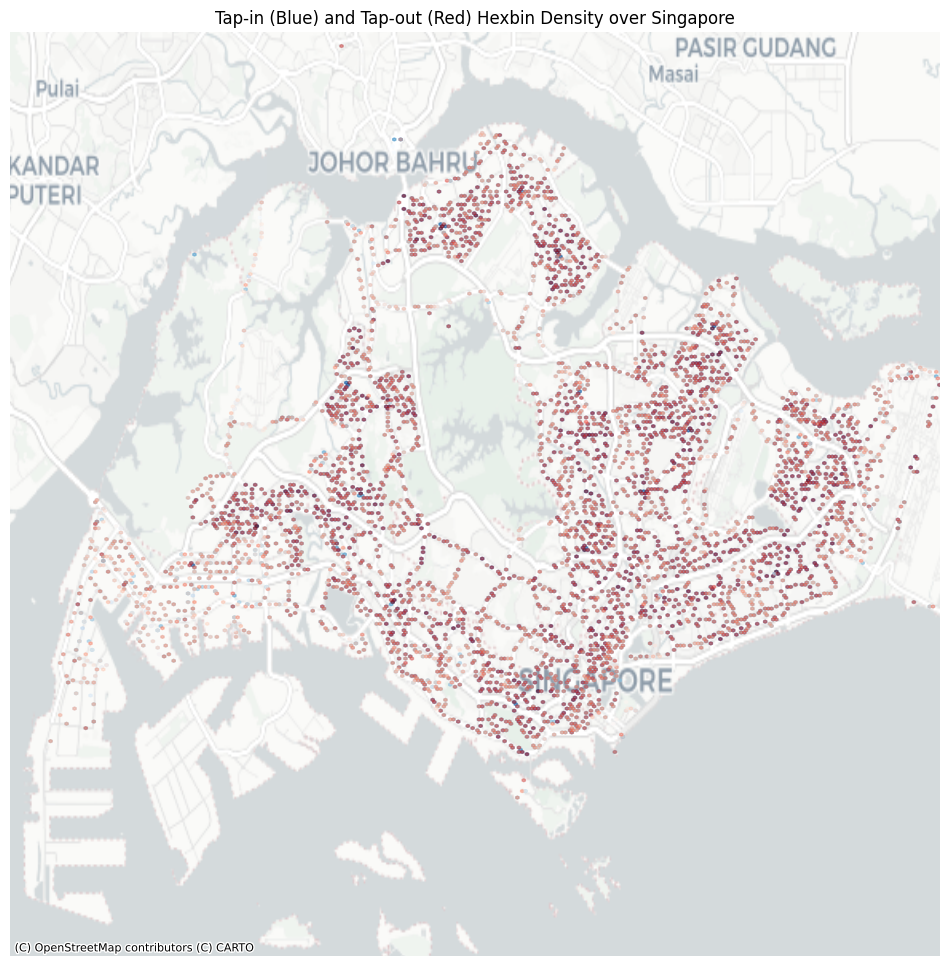

In [25]:
#plot hexbin density map
fig, ax = plt.subplots(figsize=(12,12))

# hexbin for origins (blue)
ax.hexbin(
    gdf_orig.geometry.x, gdf_orig.geometry.y, 
    gridsize=300, cmap='Blues', alpha=0.6, bins='log'
)

# hexbin for destinations (red)
ax.hexbin(
    gdf_dest.geometry.x, gdf_dest.geometry.y, 
    gridsize=300, cmap='Reds', alpha=0.4, bins='log'
)

# set visible area over sg
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)


ax.set_axis_off()
plt.title("Tap-in (Blue) and Tap-out (Red) Hexbin Density over Singapore")
plt.show()

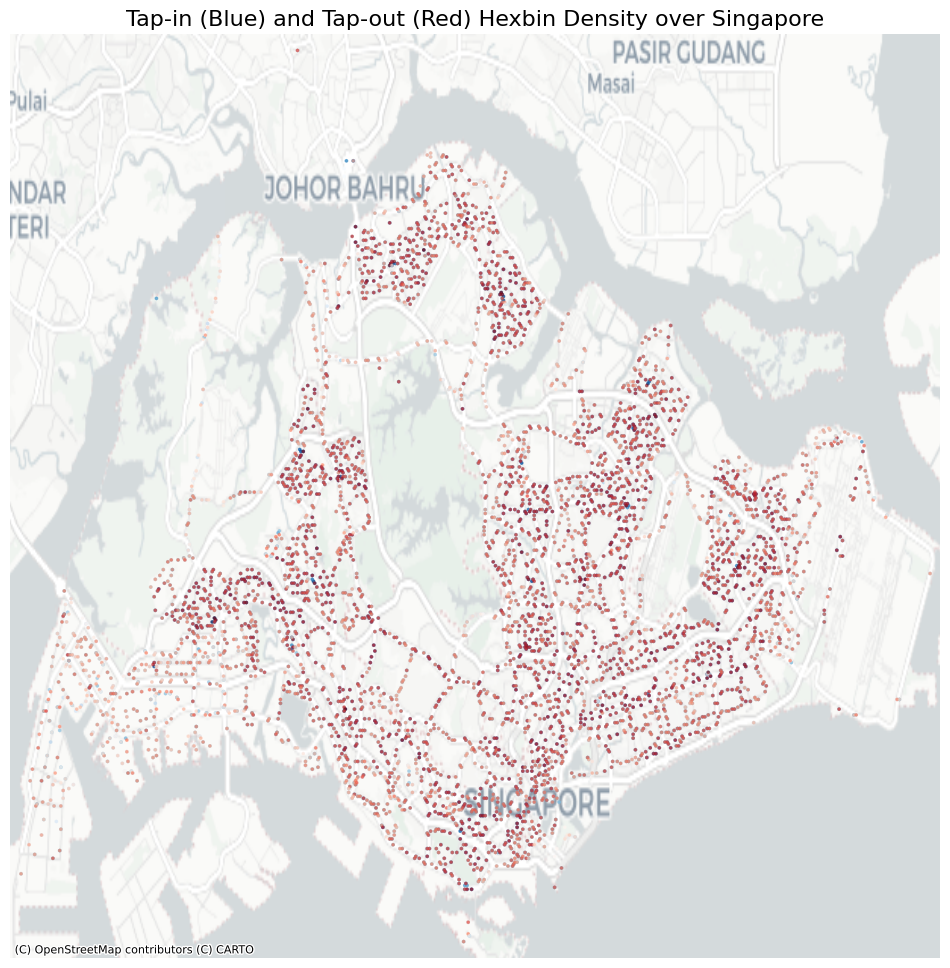

In [ ]:
#rescale hexbin to capture more dispersed tap-ins/tap-outs across Singapore
import matplotlib.pyplot as plt
import contextily as ctx

# set finer hexbin resolution
hex_gridsize = 400  # smaller hexes to capture dispersed tap-ins

fig, ax = plt.subplots(figsize=(12,12))

# origins(blue): tap-ins
hb_orig = ax.hexbin(
    gdf_orig.geometry.x, gdf_orig.geometry.y,
    gridsize=hex_gridsize, cmap='Blues',
    alpha=0.7, bins='log'
)

# destinations(red):tap-outs
hb_dest = ax.hexbin(
    gdf_dest.geometry.x, gdf_dest.geometry.y,
    gridsize=hex_gridsize, cmap='Reds',
    alpha=0.5, bins='log'
)

# set singapore extent based on data
ax.set_xlim(gdf_orig.geometry.x.min()-500, gdf_orig.geometry.x.max()+500)
ax.set_ylim(gdf_orig.geometry.y.min()-500, gdf_orig.geometry.y.max()+500)

# add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# remove axis 
ax.set_axis_off()
plt.title("Tap-in (Blue) and Tap-out (Red) Hexbin Density over Singapore", fontsize=16)
plt.show()

In [ ]:
# Count points per hex manually for origins to verify hexbin counts
x = gdf_orig.geometry.x.values
y = gdf_orig.geometry.y.values
counts, xedges, yedges = np.histogram2d(x, y, bins=400)  # same gridsize as hexbin

print("Max tap-ins per hex:", counts.max())
print("Mean tap-ins per hex:", counts.mean())

Max tap-ins per hex: 22269.0
Mean tap-ins per hex: 14.7716125


In [22]:
# Count points per hex manually for destinations
x = gdf_dest.geometry.x.values
y = gdf_dest.geometry.y.values
counts, xedges, yedges = np.histogram2d(x, y, bins=400)  # same gridsize as hexbin

print("Max tap-outs per hex:", counts.max())
print("Mean tap-outs per hex:", counts.mean())

Max tap-outs per hex: 23739.0
Mean tap-outs per hex: 14.7716125


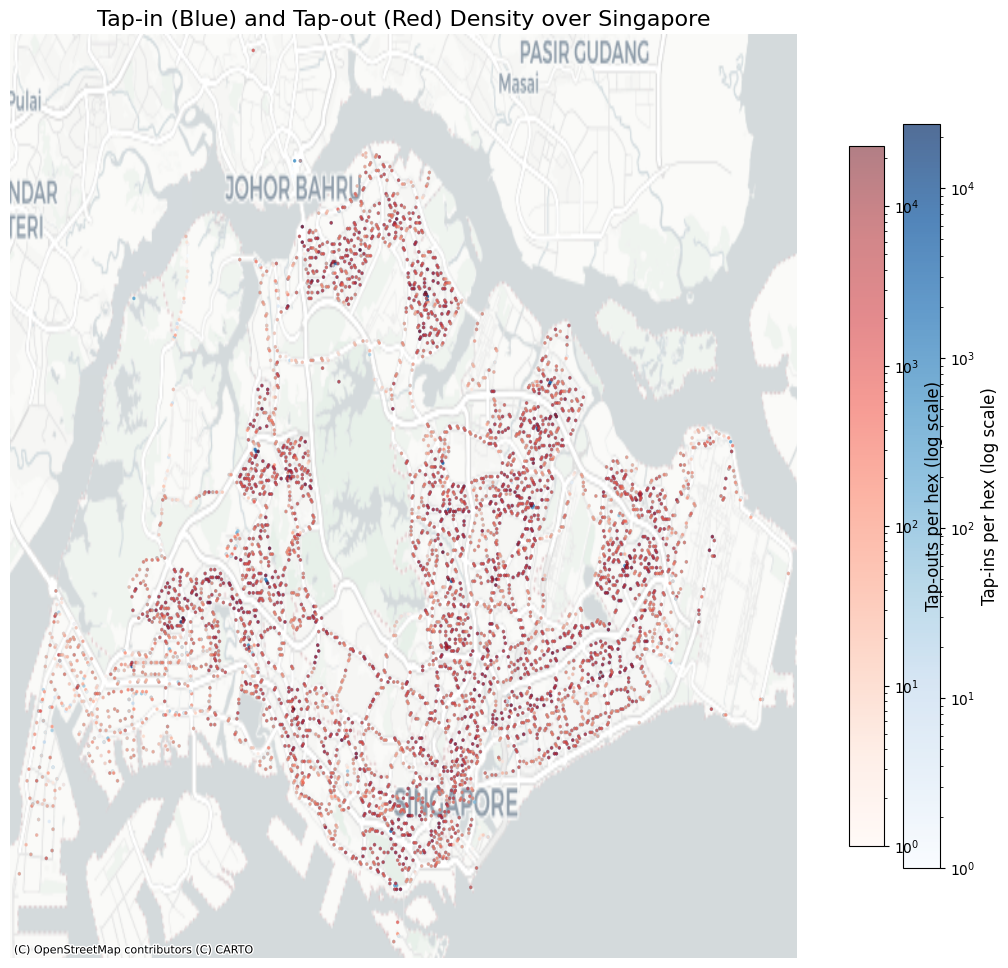

In [ ]:
# differences from previous map:
#  histogram2d helps to find the maximum count across hexes,
# so both tap-in (blue) and tap-out (red) layers share the same color scale
# includes colorbars

# extract coordinates
x_orig = gdf_orig.geometry.x.values
y_orig = gdf_orig.geometry.y.values
x_dest = gdf_dest.geometry.x.values
y_dest = gdf_dest.geometry.y.values

# use histogram2d to find maximum per hex (for consistent color scaling)
counts_orig, _, _ = np.histogram2d(x_orig, y_orig, bins=400)
counts_dest, _, _ = np.histogram2d(x_dest, y_dest, bins=400)
max_count = int(max(counts_orig.max(), counts_dest.max()))


fig, ax = plt.subplots(figsize=(12,12))

# blues are tap-ins
hb_orig = ax.hexbin(
    x_orig, y_orig,
    gridsize=400,
    bins='log',  # log scale to show sparse areas
    cmap='Blues',
    alpha=0.7,
    vmin=1, vmax=max_count
)

# red are tap-outs
hb_dest = ax.hexbin(
    x_dest, y_dest,
    gridsize=400,
    bins='log',
    cmap='Reds',
    alpha=0.5,
    vmin=1, vmax=max_count
)

#zoom to singapore context
margin = 500  # meters
ax.set_xlim(x_orig.min()-margin, x_orig.max()+margin)
ax.set_ylim(y_orig.min()-margin, y_orig.max()+margin)

# add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# add color bars
cbar_orig = fig.colorbar(hb_orig, ax=ax, fraction=0.04, pad=0.02)
cbar_orig.set_label("Tap-ins per hex (log scale)", fontsize=12)
cbar_dest = fig.colorbar(hb_dest, ax=ax, fraction=0.04, pad=0.06)
cbar_dest.set_label("Tap-outs per hex (log scale)", fontsize=12)

ax.set_axis_off()
plt.title("Tap-in (Blue) and Tap-out (Red) Density over Singapore", fontsize=16)
plt.show()